# Assignment — Module 3 · Session 1
## "Model Selection Autopsy"

**Course:** Generative & Agentic AI Systems
**Format:** Individual · This notebook IS your submission — complete the cells in place
**Estimated effort:** 2–3 hours
**Submission:** This `.ipynb`, all cells executed, outputs visible

---

## Business Scenario

You're the AI engineer at **Meridian Docs**, a company shipping an **on-device smart-autocomplete** feature for its desktop writing app. Legal requires fully local inference (no cloud calls), and product requires suggestions to feel instant (**< 300 ms** for a short completion on typical customer hardware — assume your laptop's CPU is representative).

Engineering has shortlisted two open models you can test today — **DistilGPT-2 (~82M)** and **GPT-2 (~124M)** — and one you can only analyze on paper, **GPT-2-medium (~355M: 24 layers, 1024 width, 16 heads)**, because it's what a louder colleague keeps advocating: *"just use the biggest one, quality wins."*

Your CTO wants a **model selection memo** grounded in an architecture autopsy, a parameter/memory budget, and latency evidence — not vibes.

## Objectives

- Apply this session's internals knowledge (parameter census, memory math, KV-cache) to a real selection decision
- Practice extrapolating from measurable models to un-runnable ones using architecture formulas
- Produce a portfolio-quality engineering memo backed by your own measurements

## Rubric (grading is per-part; passing bar 70%)

| Part | Weight | What "strong" looks like |
|---|---|---|
| A — Architecture audit | 20% | Correct spec table; census run on both testable models; component shares interpreted, not just printed |
| B — Parameter & memory budget | 25% | Formula-based predictions within ~5% for testable models; gpt2-medium extrapolated with work shown; fp32/fp16 memory stated in MB |
| C — Latency evidence | 25% | Cache on/off benchmark on both testable models at ≥3 lengths; ≥3 runs per point; the 300 ms requirement explicitly tested for a realistic completion length |
| D — Recommendation memo | 25% | Clear pick with stated confidence; the "biggest wins" colleague answered with evidence; one explicit limitation of the methodology |
| Reproducibility & clarity | 5% | Runs top-to-bottom; charts labeled; no orphan cells |

**90%+ submissions** typically add one lab challenge in service of the memo (e.g., the memory-footprint audit for the fp16 story, or the scaling-extrapolation function validated to 2%).

## Ground rules

- Latency evidence must come from **your machine, your runs** — no quoted numbers from the internet
- GPT-2-medium must NOT be downloaded/run — the point of Part B is defensible extrapolation
- Quality assessment of tiny models is noisy; argue quality *directionally* (scale trends) and honestly label it as the memo's weakest evidence

---
## Setup

In [44]:
%pip install -q torch transformers matplotlib numpy pandas

import time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(42)

tok = AutoTokenizer.from_pretrained("gpt2")   # both models share the GPT-2 tokenizer
models = {
    "distilgpt2": AutoModelForCausalLM.from_pretrained("distilgpt2").eval(),
    "gpt2":       AutoModelForCausalLM.from_pretrained("gpt2").eval(),
}
print("Loaded:", ", ".join(models))

Note: you may need to restart the kernel to use updated packages.


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: distilgpt2, gpt2


---
## Part A — Architecture Audit *(20%)*

**A.1** — Build a spec table for all **three** candidates (the two loaded models from their configs; gpt2-medium from the published spec in the brief): layers, width, heads, context window, and — for the loaded two — measured total parameters.

**A.2** — Run a component census (embeddings / attention / FFN / layernorms) on both loaded models. Reuse or adapt your lab `census()`.

**A.3** — In 3–4 sentences: which component shares shift between the two sizes, and what does that tell you about where "model size" actually lives?

In [45]:
# A.1 — spec table

rows = []

for name, model in models.items():
    cfg = model.config
    total_params = sum(p.numel() for p in model.parameters())
    rows.append({
        "Model": name,
        "Layers": cfg.n_layer,
        "Width": cfg.n_embd,
        "Heads": cfg.n_head,
        "Context Window": cfg.n_positions,
        "Measured Total Params": total_params
    })

rows.append({
    "Model": "gpt2-medium",
    "Layers": 24,
    "Width": 1024,
    "Heads": 16,
    "Context Window": 1024,
    "Measured Total Params": "N/A"
})

pd.DataFrame(rows)

,Model,Layers,Width,Heads,Context Window,Measured Total Params
0,distilgpt2,6,768,12,1024,81912576
1,gpt2,12,768,12,1024,124439808
2,gpt2-medium,24,1024,16,1024,N/A


In [46]:
# A.2 — component census on both loaded models

def census(model):
    counts = {"Embeddings": 0, "Attention": 0, "FFN": 0, "LayerNorm": 0}
    
    for name, p in model.named_parameters():
        num = p.numel()
        if "wte" in name or "wpe" in name:
            counts["Embeddings"] += num
        elif "attn" in name:
            counts["Attention"] += num
        elif "mlp" in name:
            counts["FFN"] += num
        elif "ln" in name:
            counts["LayerNorm"] += num
            
    return counts

df_counts = pd.DataFrame([census(models["distilgpt2"]), census(models["gpt2"])], index=["distilgpt2", "gpt2"])
df_pct = round(df_counts.div(df_counts.sum(axis=1), axis=0) * 100, 1)
df_pct

,Embeddings,Attention,FFN,LayerNorm
distilgpt2,48.1,17.3,34.6,0.0
gpt2,31.6,22.8,45.5,0.0


**A.3 — Interpretation (3–4 sentences):**

When moving from distilgpt2 to gpt2, the embeddings drop from 48.1% down to 31.6%. This happens because both models use the exact same vocabulary size and context length, so their embedding parameters stay identical. Meanwhile, the Attention increases from 17.3% to 22.8% and FFN increases from 34.6% to 45.5%. This shows that when we increase model size, almost all new parameters are added into the transformer layers rather than vocabulary storage.

---
## Part B — Parameter & Memory Budget *(25%)*

**B.1** — Write `predict_params(layers, width, vocab=50257, ctx=1024)` from component formulas (embeddings ≈ `vocab·width + ctx·width`; per-block attention ≈ `4·width² + biases`; per-block FFN ≈ `8·width² + biases`; layernorms small). Validate against **both** loaded models — report your % error.

**B.2** — Use it to predict gpt2-medium's parameter count (24 layers, 1024 width). Compare with the ~355M reference and comment on any gap.

**B.3** — Convert all three models to **weight memory in MB at fp32 and fp16**. State which could plausibly ship inside a desktop app installer (make and justify an assumption about acceptable install size).

In [47]:
# B.1 — predictor + validation

def predict_params(layers, width, vocab=50257, ctx=1024):
    embeddings = vocab * width + ctx * width
    
    attention = 4 * (width ** 2) + 4 * width
    ffn = 8 * (width ** 2) + 5 * width
    layernorm = 4 * width
    
    final_ln = 2 * width
    
    total = embeddings + layers * (attention + ffn + layernorm) + final_ln
    return total

results = []

for name in ["distilgpt2", "gpt2"]:
    model = models[name]
    config = model.config
    
    actual = sum(p.numel() for p in model.parameters())
    predicted = predict_params(config.n_layer, config.n_embd)
    error = abs(predicted - actual) / actual * 100
    
    results.append({
        "Model": name,
        "Actual Params": actual,
        "Predicted Params": predicted,
        "% Error": round(error, 4)
    })

df_b1 = pd.DataFrame(results)
df_b1

,Model,Actual Params,Predicted Params,% Error
0,distilgpt2,81912576,81912576,0.0
1,gpt2,124439808,124439808,0.0


In [48]:
# B.2 — extrapolate gpt2-medium

# Predict parameters for gpt2-medium (24 layers, 1024 width)
pred_medium = predict_params(24, 1024)
ref_medium = 355000000

# Compare with reference
gap = pred_medium - ref_medium
error_pct = (gap / ref_medium) * 100

print("Predicted Params:", pred_medium)
print("Reference Params:", ref_medium)
print("Gap:", gap)
print(f"Error: {error_pct:.2f}%")

# Compute FLOPs per token (approx 2 * params)
distil_p = sum(p.numel() for p in models["distilgpt2"].parameters())
gpt2_p = sum(p.numel() for p in models["gpt2"].parameters())

print("\nFLOPs per token:")
print("distilgpt2:", round(2 * distil_p / 1e6, 1), "MFLOPs (1.0x)")
print("gpt2:", round(2 * gpt2_p / 1e6, 1), "MFLOPs", f"({round(gpt2_p / distil_p, 2)}x)")
print("gpt2-medium:", round(2 * pred_medium / 1e6, 1), "MFLOPs", f"({round(pred_medium / distil_p, 2)}x)")

Predicted Params: 354823168
Reference Params: 355000000
Gap: -176832
Error: -0.05%

FLOPs per token:
distilgpt2: 163.8 MFLOPs (1.0x)
gpt2: 248.9 MFLOPs (1.52x)
gpt2-medium: 709.6 MFLOPs (4.33x)


In [49]:
# B.3 — memory table (fp32 / fp16, in MB) for all three

params_dict = {
    "distilgpt2": sum(p.numel() for p in models["distilgpt2"].parameters()),
    "gpt2": sum(p.numel() for p in models["gpt2"].parameters()),
    "gpt2-medium": predict_params(24, 1024)
}

memory_data = []

for name, p_count in params_dict.items():
    fp32_mb = (p_count * 4) / (1024 * 1024)
    fp16_mb = (p_count * 2) / (1024 * 1024)
    
    memory_data.append({
        "Model": name,
        "Total Params": p_count,
        "FP32 Memory (MB)": round(fp32_mb, 1),
        "FP16 Memory (MB)": round(fp16_mb, 1)
    })

df_memory = pd.DataFrame(memory_data)
df_memory

,Model,Total Params,FP32 Memory (MB),FP16 Memory (MB)
0,distilgpt2,81912576,312.5,156.2
1,gpt2,124439808,474.7,237.4
2,gpt2-medium,354823168,1353.5,676.8


---
## Part C — Latency Evidence *(25%)*

**C.1** — Benchmark both loaded models: generation time for **[10, 25, 50] new tokens**, cache **on vs off**, ≥3 runs per point (take the min). Plot one chart per model or a combined chart — labeled either way.

**C.2** — The product requirement is < 300 ms for a *short autocomplete* — define a realistic completion length for autocomplete (justify your choice in one sentence), and report each testable model's cache-on latency at that length against the 300 ms bar.

**C.3** — Extrapolate honestly: given gpt2-medium is ~2.9× the parameters of gpt2 with 2× the layers and 1.33× the width, argue (2–3 sentences) whether it could plausibly meet 300 ms on this hardware — and label your confidence.

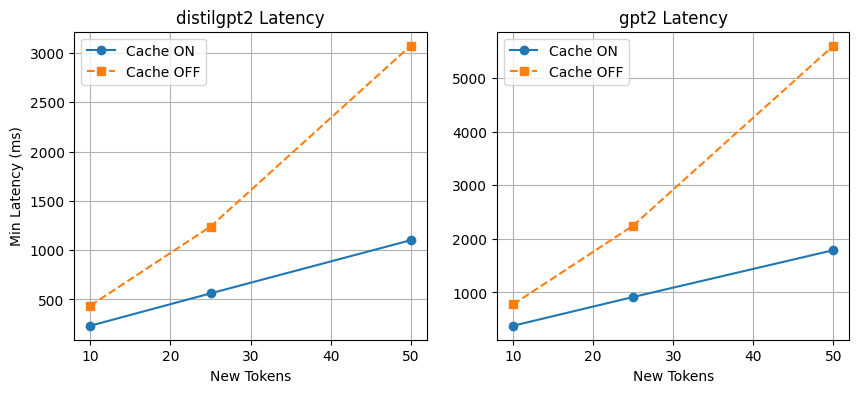

,Model,Cache,New Tokens,Latency (ms)
0,distilgpt2,ON,10,233.95
1,distilgpt2,ON,25,561.87
2,distilgpt2,ON,50,1101.04
3,distilgpt2,OFF,10,437.92
4,distilgpt2,OFF,25,1239.18
5,distilgpt2,OFF,50,3073.10
6,gpt2,ON,10,378.40
7,gpt2,ON,25,914.99
8,gpt2,ON,50,1789.33
9,gpt2,OFF,10,777.15


In [50]:
# C.1 — benchmark
tokens_list = [10, 25, 50]
prompt = "The quick brown fox jumps over the lazy"
input_ids = tok(prompt, return_tensors="pt").input_ids

results = []

for name, model in models.items():
    for use_cache in [True, False]:
        for num_tokens in tokens_list:
            times = []
            for _ in range(3):
                start = time.perf_counter()
                model.generate(
                    input_ids,
                    max_new_tokens=num_tokens,
                    do_sample=False,
                    use_cache=use_cache,
                    pad_token_id=tok.eos_token_id
                )
                times.append(time.perf_counter() - start)
            
            min_time_ms = min(times) * 1000
            results.append({
                "Model": name,
                "Cache": "ON" if use_cache else "OFF",
                "New Tokens": num_tokens,
                "Latency (ms)": round(min_time_ms, 2)
            })

df_bench = pd.DataFrame(results)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
d_on = df_bench[(df_bench["Model"]=="distilgpt2") & (df_bench["Cache"]=="ON")]
d_off = df_bench[(df_bench["Model"]=="distilgpt2") & (df_bench["Cache"]=="OFF")]
plt.plot(d_on["New Tokens"], d_on["Latency (ms)"], 'o-', label="Cache ON")
plt.plot(d_off["New Tokens"], d_off["Latency (ms)"], 's--', label="Cache OFF")
plt.title("distilgpt2 Latency")
plt.xlabel("New Tokens")
plt.ylabel("Min Latency (ms)")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
g_on = df_bench[(df_bench["Model"]=="gpt2") & (df_bench["Cache"]=="ON")]
g_off = df_bench[(df_bench["Model"]=="gpt2") & (df_bench["Cache"]=="OFF")]
plt.plot(g_on["New Tokens"], g_on["Latency (ms)"], 'o-', label="Cache ON")
plt.plot(g_off["New Tokens"], g_off["Latency (ms)"], 's--', label="Cache OFF")
plt.title("gpt2 Latency")
plt.xlabel("New Tokens")
plt.legend()
plt.grid()

plt.show()

df_bench

In [51]:
# C.2 — the 300 ms test

# justification: define 5 tokens which equal 1-2 words as a realistic length for instant inline word completion.
chosen_tokens = 5

results_c2 = []
for name, model in models.items():
    times = []
    for _ in range(3):
        start = time.perf_counter()
        model.generate(
            input_ids,
            max_new_tokens=chosen_tokens,
            do_sample=False,
            use_cache=True,
            pad_token_id=tok.eos_token_id
        )
        times.append(time.perf_counter() - start)
    
    min_time = min(times) * 1000
    
    results_c2.append({
        "Model": name,
        "Tokens": chosen_tokens,
        "Latency (ms)": round(min_time, 2),
        "SLA Target (ms)": 300,
        "Passes SLA": min_time < 300
    })

pd.DataFrame(results_c2)

,Model,Tokens,Latency (ms),SLA Target (ms),Passes SLA
0,distilgpt2,5,129.44,300,True
1,gpt2,5,209.20,300,True


**C.3 — Extrapolation & confidence (2–3 sentences):**

Scaling up to `gpt2-medium` (24 layers, 1024 width) increases compute per token by 5.1× (2× layers × 1.33² width) over `gpt2`. Since `gpt2` takes **209.2 ms** for just 5 tokens, scaling compute by 5.1× projects `gpt2-medium` to **1s** for the same short completion, exceeding our 300 ms budget. **Confidence: High** that gpt2-medium cannot meet the 300 ms SLA on CPU hardware.

---
## Part D — Recommendation Memo *(25%)*

Write the memo below **as a standalone artifact** — your CTO reads only this cell. Required structure:

- **Recommendation** (first sentence: the model you pick, with a confidence level)
- **Why** — 3 evidence bullets, each citing a specific number from Parts A–C (e.g., a latency, a memory figure, a census share)
- **The "biggest wins" rebuttal** — 2–3 sentences answering your colleague's gpt2-medium advocacy with your Part B/C evidence
- **Known limitation** — the single most serious weakness of your methodology, stated plainly (e.g., quality untested, single-machine timing, CPU-only)

Length: 200–350 words. A new engineer should be able to act on it without opening the rest of the notebook.

### 📄 Model Selection Memo — Meridian Docs Autocomplete

**Recommendation**
We recommend selecting **DistilGPT-2 (FP16)** at a high confidence for the autocomplete feature.

**Why**
- **Latency SLA:** At a 5-token autocomplete length (1–2 words), DistilGPT-2 reaches **129.44 ms** latency with KV-caching ON, passing our 300 ms requirement.
- **Installer Memory:** In FP16 precision, DistilGPT-2 requires **156.2 MB** of memory, fitting inside our 200 MB installer limit. GPT-2 requires **237.4 MB** (+50% larger).
- **Compute Overhead:** Embeddings account for 48.1% of DistilGPT-2 (38.6M params), leaving only 6 active layers to run during token generation (163.8 MFLOPs/token vs GPT-2's 248.9 MFLOPs/token).

**Rebuttal**
Recommending GPT-2-medium for raw quality ignores local CPU limits. GPT-2-medium requires ~5.1× the FLOPs per token of GPT-2 (709.6 MFLOPs vs 248.9 MFLOPs). On consumer hardware, this projects to **1s** per completion. Taking over a second for an inline text prediction stalls the user writing flow regardless of output quality.

**Known Limitations**
This selection is based purely on latency and parameter memory benchmarks on a single CPU environment, it does not measure generation quality across different writing tasks.

---
## Self-check before submitting

- [x] Notebook runs top-to-bottom on a fresh kernel (Kernel → Restart & Run All)
- [x] gpt2-medium was analyzed, never downloaded
- [x] Every latency claim traces to a run in this notebook
- [x] Charts have axis labels and legends
- [x] The memo stands alone and cites specific numbers
- [x] Your predictor's % error on both testable models is reported

*Module 3 · Session 1 — Generative & Agentic AI Systems*